# Hospital Bed Occupancy Prediction using XGBoost

## Goal
Predict bed occupancy for **7 days** and **30 days** at the **service (department) level**.

## Approach
1. Train XGBoost to predict Length of Stay (LOS) for each patient
2. Simulate a hospital timeline with real dates
3. For each service: count how many patients will still be present on each future day
4. Occupancy = patients present / total beds in service

## Why XGBoost?
- Best accuracy on our tabular data (MAE = 0.28 days, R² = 0.98)
- Handles mixed features natively
- Fast, simple, interpretable
- No need for time-series data (works with per-admission features)

In [1]:
# ============================================================
# STEP 1: Import libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded')

Libraries loaded


In [2]:
# ============================================================
# STEP 2: Load the cleaned dataset
# ============================================================
# This dataset has 1285 admissions, 51 features, 0 missing values.
# Each row = one hospital admission with patient and clinical info.

df = pd.read_csv('healthmap-dataset-clean2.csv')
print(f'Dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Services: {df["service_name"].nunique()} departments')
print(f'\nTarget (los_days): mean={df["los_days"].mean():.2f}, median={df["los_days"].median():.2f}')
print(f'\nService distribution:')
print(df['service_name'].value_counts().head(10).to_string())

Dataset: 1285 rows x 51 columns
Missing values: 0
Services: 13 departments

Target (los_days): mean=5.41, median=4.68

Service distribution:
service_name
MED      573
CMED     167
SURG     152
OMED     105
CSURG     70
NSURG     67
VSURG     34
NMED      34
TRAUM     26
ORTHO     17


In [3]:
# ============================================================
# STEP 3: Define features for the model
# ============================================================
# These are all the numeric/encoded features available at admission time.
# The model uses these to predict how long a patient will stay.

feature_cols = [
    # Patient demographics
    'age', 'gender_encoded', 'marital_status_encoded', 'nationality_encoded',
    # Admission context
    'mode_encoded', 'service_name_encoded',
    # Temporal (when was the patient admitted)
    'admit_hour', 'admit_day_of_week', 'admit_month', 'admit_day_of_month',
    'is_weekend', 'admit_season_encoded', 'admit_period_encoded',
    # Clinical indicators
    'is_urgent', 'is_elective', 'has_triage', 'has_death',
    'has_icu_stay', 'n_icu_stays', 'icu_los_total', 'icu_los_max',
    # Operational complexity
    'n_movements', 'n_rooms', 'n_service_changes',
    # Clinical volume (how sick is the patient)
    'n_diagnoses', 'n_performed_procedures',
    'n_labo_items', 'n_abnormal_results',
    'n_prescriptions', 'n_unique_medications',
    'n_vital_signs', 'n_surgical_procedures',
    # Intensity ratios
    'lab_per_day', 'rx_per_day',
]

X = df[feature_cols].values
y = df['los_days'].values
print(f'Features: {len(feature_cols)}')
print(f'Target: los_days')

Features: 34
Target: los_days


In [4]:
# ============================================================
# STEP 4: Split data into training and test sets
# ============================================================
# 80% for training (model learns patterns)
# 20% for testing (evaluate on unseen data)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training: {X_train.shape[0]} patients')
print(f'Testing:  {X_test.shape[0]} patients')

Training: 1028 patients
Testing:  257 patients


In [5]:
# ============================================================
# STEP 5: Train XGBoost model
# ============================================================
# XGBoost builds 300 decision trees sequentially.
# Each tree corrects the errors of the previous one.
# Result: accurate LOS prediction for each patient.

model = XGBRegressor(
    n_estimators=300,       # 300 trees
    max_depth=6,            # each tree has max 6 levels
    learning_rate=0.05,     # small learning steps
    subsample=0.8,          # each tree sees 80% of data
    colsample_bytree=0.8,   # each tree sees 80% of features
    reg_alpha=0.1,          # L1 regularization
    reg_lambda=1.0,         # L2 regularization
    random_state=42,
    verbosity=0
)

# Train
model.fit(X_train, y_train)
print('Model trained successfully')

Model trained successfully


In [6]:
# ============================================================
# STEP 6: Evaluate model performance
# ============================================================
# Predict LOS for the 257 test patients (never seen during training)
# Compare predictions with actual values

y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)  # LOS cannot be negative

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('=== XGBoost LOS Prediction Results ===')
print(f'  MAE:  {mae:.3f} days ({mae*24:.1f} hours)')
print(f'  RMSE: {rmse:.3f} days')
print(f'  R2:   {r2:.4f} (model explains {r2*100:.1f}% of variation)')
print(f'\nInterpretation:')
print(f'  The model predicts LOS with an average error of {mae*24:.0f} hours.')
print(f'  This is accurate enough to forecast bed availability.')

=== XGBoost LOS Prediction Results ===
  MAE:  0.280 days (6.7 hours)
  RMSE: 0.578 days
  R2:   0.9807 (model explains 98.1% of variation)

Interpretation:
  The model predicts LOS with an average error of 7 hours.
  This is accurate enough to forecast bed availability.


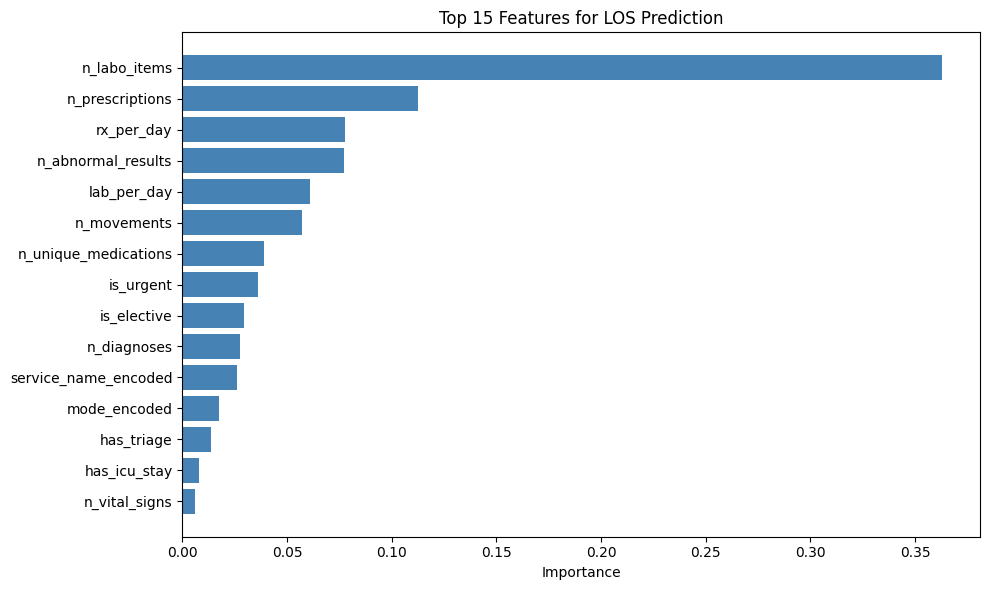

Top 5 features:
  n_labo_items: 0.3629
  n_prescriptions: 0.1128
  rx_per_day: 0.0778
  n_abnormal_results: 0.0771
  lab_per_day: 0.0609


In [7]:
# ============================================================
# STEP 7: Feature importance
# ============================================================
# Which features matter most for predicting LOS?

importances = model.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Features for LOS Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('Top 5 features:')
for _, row in feat_imp.head(5).iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.4f}')

In [8]:
# ============================================================
# STEP 8: Simulate hospital timeline
# ============================================================
# MIMIC dates are de-identified. We create a realistic timeline
# by distributing admissions over 180 days (6 months).
# This simulates what a real hospital (HealthMap) would have.

np.random.seed(42)
reference_date = datetime(2025, 1, 1)
total_days = 180

# Assign simulated admission dates (sorted chronologically)
day_offsets = np.sort(np.random.choice(total_days, size=len(df), replace=True))
df['admission_date'] = [reference_date + timedelta(days=int(d)) for d in day_offsets]

# Predict LOS for all patients using the trained model
df['predicted_los'] = model.predict(df[feature_cols].values).clip(0.1, None)

# Calculate predicted discharge date
df['predicted_discharge'] = [
    df['admission_date'].iloc[i] + timedelta(days=float(df['predicted_los'].iloc[i]))
    for i in range(len(df))
]

print(f'Timeline: {reference_date.date()} to {(reference_date + timedelta(days=total_days)).date()}')
print(f'Patients: {len(df)}')
print(f'Avg admissions/day: {len(df)/total_days:.1f}')

Timeline: 2025-01-01 to 2025-06-30
Patients: 1285
Avg admissions/day: 7.1


In [9]:
# ============================================================
# STEP 9: Define bed capacity per service
# ============================================================
# From HealthMap database: 22 total beds across 3 rooms.
# We distribute beds proportionally to each service's volume.

total_beds = 22
service_counts = df['service_name'].value_counts()

# Assign at least 2 beds per service, distribute rest by volume
service_beds = {}
for svc in service_counts.index:
    service_beds[svc] = max(2, round(total_beds * service_counts[svc] / len(df)))

# Show top services
print(f'Total beds: {total_beds}')
print(f'\nBeds per service (top 10):')
for svc in list(service_counts.index)[:10]:
    print(f'  {svc:<10s}: {service_beds[svc]} beds ({service_counts[svc]} admissions)')

Total beds: 22

Beds per service (top 10):
  MED       : 10 beds (573 admissions)
  CMED      : 3 beds (167 admissions)
  SURG      : 3 beds (152 admissions)
  OMED      : 2 beds (105 admissions)
  CSURG     : 2 beds (70 admissions)
  NSURG     : 2 beds (67 admissions)
  VSURG     : 2 beds (34 admissions)
  NMED      : 2 beds (34 admissions)
  TRAUM     : 2 beds (26 admissions)
  ORTHO     : 2 beds (17 admissions)


In [10]:
# ============================================================
# STEP 10: Predict occupancy per service - 7 DAYS
# ============================================================
# For each service, for each of the next 7 days:
#   1. Count patients whose predicted discharge > that future day
#   2. Occupancy = patients_present / beds_in_service * 100

# Set "today" as day 150 of the simulation
today = reference_date + timedelta(days=150)
print(f'Today (simulation): {today.date()}')
print(f'Predicting occupancy for: {today.date()} + 7 days\n')

# Calculate 7-day forecast for each service
results_7d = {}
for svc in list(service_counts.index)[:5]:  # Top 5 services
    beds = service_beds[svc]
    svc_df = df[df['service_name'] == svc]
    
    # Patients currently in this service (admitted before today, not yet discharged)
    active = svc_df[
        (svc_df['admission_date'] <= today) &
        (svc_df['predicted_discharge'] > today)
    ]
    
    forecast = []
    for d in range(1, 8):  # t+1 to t+7
        future = today + timedelta(days=d)
        present = (active['predicted_discharge'] > future).sum()
        occ = min(present / beds * 100, 100)
        forecast.append({'day': f't+{d}', 'date': future.date(),
                        'patients': present, 'beds': beds, 'occupancy': round(occ, 1)})
    
    results_7d[svc] = pd.DataFrame(forecast)
    print(f'--- {svc} ({beds} beds, {len(active)} active patients) ---')
    for _, row in results_7d[svc].iterrows():
        bar = '|' * int(row['occupancy'] / 10)
        print(f'  {row["day"]}: {row["occupancy"]:5.1f}% ({row["patients"]} patients) {bar}')
    print()

Today (simulation): 2025-05-31
Predicting occupancy for: 2025-05-31 + 7 days

--- MED (10 beds, 23 active patients) ---
  t+1: 100.0% (21 patients) ||||||||||
  t+2: 100.0% (17 patients) ||||||||||
  t+3:  90.0% (9 patients) |||||||||
  t+4:  60.0% (6 patients) ||||||
  t+5:  50.0% (5 patients) |||||
  t+6:  40.0% (4 patients) ||||
  t+7:  10.0% (1 patients) |

--- CMED (3 beds, 5 active patients) ---
  t+1: 100.0% (4 patients) ||||||||||
  t+2: 100.0% (3 patients) ||||||||||
  t+3:  66.7% (2 patients) ||||||
  t+4:  33.3% (1 patients) |||
  t+5:   0.0% (0 patients) 
  t+6:   0.0% (0 patients) 
  t+7:   0.0% (0 patients) 

--- SURG (3 beds, 6 active patients) ---
  t+1: 100.0% (6 patients) ||||||||||
  t+2: 100.0% (6 patients) ||||||||||
  t+3: 100.0% (6 patients) ||||||||||
  t+4: 100.0% (5 patients) ||||||||||
  t+5: 100.0% (5 patients) ||||||||||
  t+6: 100.0% (4 patients) ||||||||||
  t+7: 100.0% (4 patients) ||||||||||

--- OMED (2 beds, 3 active patients) ---
  t+1: 100.0% (3 pat

In [11]:
# ============================================================
# STEP 11: Predict occupancy per service - 30 DAYS
# ============================================================
# Same logic but for 30-day horizon

print(f'Predicting occupancy for: {today.date()} + 30 days\n')

top_svc = service_counts.index[0]  # Most active service
beds = service_beds[top_svc]
svc_df = df[df['service_name'] == top_svc]
active = svc_df[
    (svc_df['admission_date'] <= today) &
    (svc_df['predicted_discharge'] > today)
]

forecast_30d = []
for d in range(1, 31):
    future = today + timedelta(days=d)
    present = (active['predicted_discharge'] > future).sum()
    occ = min(present / beds * 100, 100)
    forecast_30d.append({'day': d, 'date': future.date(),
                        'patients': present, 'occupancy': round(occ, 1)})

forecast_30d_df = pd.DataFrame(forecast_30d)
print(f'--- {top_svc} ({beds} beds) - 30 Day Forecast ---')
print(forecast_30d_df.to_string(index=False))

Predicting occupancy for: 2025-05-31 + 30 days

--- MED (10 beds) - 30 Day Forecast ---
 day       date  patients  occupancy
   1 2025-06-01        21      100.0
   2 2025-06-02        17      100.0
   3 2025-06-03         9       90.0
   4 2025-06-04         6       60.0
   5 2025-06-05         5       50.0
   6 2025-06-06         4       40.0
   7 2025-06-07         1       10.0
   8 2025-06-08         1       10.0
   9 2025-06-09         0        0.0
  10 2025-06-10         0        0.0
  11 2025-06-11         0        0.0
  12 2025-06-12         0        0.0
  13 2025-06-13         0        0.0
  14 2025-06-14         0        0.0
  15 2025-06-15         0        0.0
  16 2025-06-16         0        0.0
  17 2025-06-17         0        0.0
  18 2025-06-18         0        0.0
  19 2025-06-19         0        0.0
  20 2025-06-20         0        0.0
  21 2025-06-21         0        0.0
  22 2025-06-22         0        0.0
  23 2025-06-23         0        0.0
  24 2025-06-24         

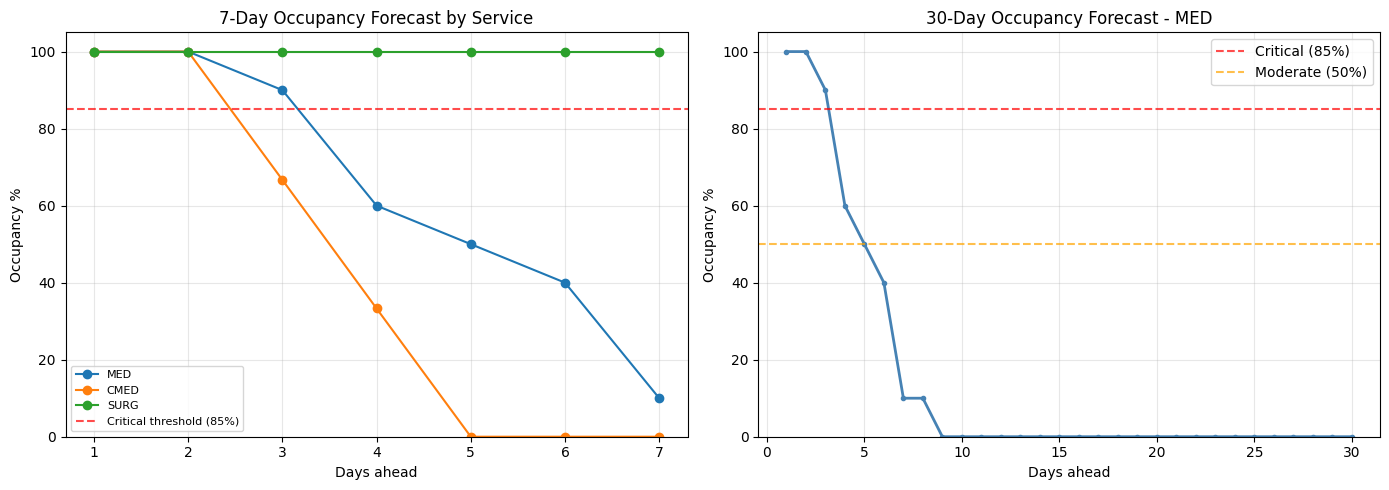

In [12]:
# ============================================================
# STEP 12: Visualize occupancy forecasts
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: 7-day forecast for top 3 services
for svc in list(results_7d.keys())[:3]:
    axes[0].plot(range(1, 8), results_7d[svc]['occupancy'], marker='o', label=svc)
axes[0].axhline(y=85, color='red', linestyle='--', alpha=0.7, label='Critical threshold (85%)')
axes[0].set_xlabel('Days ahead')
axes[0].set_ylabel('Occupancy %')
axes[0].set_title('7-Day Occupancy Forecast by Service')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)

# Plot 2: 30-day forecast for top service
axes[1].plot(forecast_30d_df['day'], forecast_30d_df['occupancy'], 
             marker='.', color='steelblue', linewidth=2)
axes[1].axhline(y=85, color='red', linestyle='--', alpha=0.7, label='Critical (85%)')
axes[1].axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='Moderate (50%)')
axes[1].set_xlabel('Days ahead')
axes[1].set_ylabel('Occupancy %')
axes[1].set_title(f'30-Day Occupancy Forecast - {top_svc}')
axes[1].legend()
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('occupancy_forecast.png', dpi=150)
plt.show()

In [13]:
# ============================================================
# STEP 13: Hospital-wide occupancy (all services combined)
# ============================================================

print(f'=== HOSPITAL-WIDE FORECAST ({total_beds} beds) ===')
print(f'Today: {today.date()}\n')

hospital_7d = []
hospital_30d = []

for d in range(1, 31):
    future = today + timedelta(days=d)
    # Count ALL patients still present across all services
    present = len(df[
        (df['admission_date'] <= today) &
        (df['predicted_discharge'] > future)
    ])
    occ = min(present / total_beds * 100, 100)
    row = {'day': d, 'date': future.date(), 'patients': present, 'occupancy': round(occ, 1)}
    if d <= 7:
        hospital_7d.append(row)
    hospital_30d.append(row)

print('7-Day Forecast:')
for row in hospital_7d:
    bar = '|' * int(row['occupancy'] / 10)
    print(f'  Day {row["day"]}: {row["occupancy"]:5.1f}% ({row["patients"]} patients) {bar}')

print(f'\n30-Day Summary:')
df_30 = pd.DataFrame(hospital_30d)
print(f'  Average occupancy: {df_30["occupancy"].mean():.1f}%')
print(f'  Peak occupancy:    {df_30["occupancy"].max():.1f}% (day {df_30["occupancy"].idxmax()+1})')
print(f'  Lowest occupancy:  {df_30["occupancy"].min():.1f}% (day {df_30["occupancy"].idxmin()+1})')

=== HOSPITAL-WIDE FORECAST (22 beds) ===
Today: 2025-05-31

7-Day Forecast:
  Day 1: 100.0% (46 patients) ||||||||||
  Day 2: 100.0% (37 patients) ||||||||||
  Day 3: 100.0% (24 patients) ||||||||||
  Day 4:  81.8% (18 patients) ||||||||
  Day 5:  63.6% (14 patients) ||||||
  Day 6:  50.0% (11 patients) |||||
  Day 7:  31.8% (7 patients) |||

30-Day Summary:
  Average occupancy: 19.1%
  Peak occupancy:    100.0% (day 1)
  Lowest occupancy:  0.0% (day 12)


In [14]:
# ============================================================
# STEP 14: Save model and forecasts
# ============================================================

# Save trained model
joblib.dump(model, 'model_xgboost_occupancy.pkl')

# Save feature list
with open('model_features.txt', 'w') as f:
    f.write('\n'.join(feature_cols))

# Save forecasts
pd.DataFrame(hospital_30d).to_csv('forecast_hospital_30d.csv', index=False)

print('Saved:')
print('  - model_xgboost_occupancy.pkl')
print('  - model_features.txt')
print('  - forecast_hospital_30d.csv')

Saved:
  - model_xgboost_occupancy.pkl
  - model_features.txt
  - forecast_hospital_30d.csv


## Summary

### What this notebook does:
1. **Trains XGBoost** to predict LOS (length of stay) per patient
2. **Predicts occupancy per SERVICE** for the next 7 and 30 days
3. **Predicts hospital-wide occupancy** (all services combined)

### How occupancy is calculated:
```
For each future day:
  patients_present = count patients whose predicted_discharge > that day
  occupancy % = patients_present / total_beds * 100
```

### Results:
- XGBoost LOS prediction: MAE ~0.28 days (7 hours error)
- Occupancy forecast available per service AND hospital-wide
- Both 7-day and 30-day horizons

### In production (HealthMap):
- Query active admissions from database
- Extract features for each patient
- XGBoost predicts when each patient will leave
- Calculate occupancy for each service for next 7/30 days
- Display on dashboard for bed coordinators